# PHASE 2: Data Cleaning & Quality Checks
**Traceability**
- Issue ID: #2 Data Cleaning & Quality Checks

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Constant Sensor Removal)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Outlier Handling)

## 1. Objectives
- **Diagnostic**: Identify sensors with zero variance (constant).
- **Action**: Remove constant sensors to reduce dimensionality.
- **Diagnostic**: Detect outliers using statistical distribution plots.
- **Action**: Clip outliers to 1st/99th percentiles to preserve temporal continuity.

In [51]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']
COLORSplt = ['#313695', '#4575B4', '#FFFFFF', '#FEE090', '#D73027']

# ── Reproducibility Config ──────────────────────────────────────────────
np.random.seed(42)

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COL_NAMES = (
    ['unit_number', 'time_cycles'] +
    ['setting_1', 'setting_2', 'setting_3'] +
    [f's_{i}' for i in range(1, 22)]   # s_1 ... s_21
)

### 2.1 Load Raw Data
Load the raw training and test data.

In [52]:
df_train = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
df_test = pd.read_csv(DATA_DIR / 'test_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
print(f"✅ Data loaded: Train {df_train.shape}, Test {df_test.shape}")

✅ Data loaded: Train (20631, 26), Test (13096, 26)


### 2.2 Diagnostic: Sensor Variance Analysis
We visualize the standard deviation of each sensor to identify those that do not change over time (constant sensors). These provide no predictive value.

s_1: 0.0000
s_19: 0.0000
s_18: 0.0000
s_10: 0.0000
s_16: 0.0000
s_5: 0.0000
s_6: 0.0014
s_15: 0.0375
s_8: 0.0710
s_13: 0.0719
s_21: 0.1083
s_20: 0.1807
s_11: 0.2671
s_2: 0.5001
s_12: 0.7376
s_7: 0.8851
s_17: 1.5488
s_3: 6.1311
s_4: 9.0006
s_14: 19.0762
s_9: 22.0829


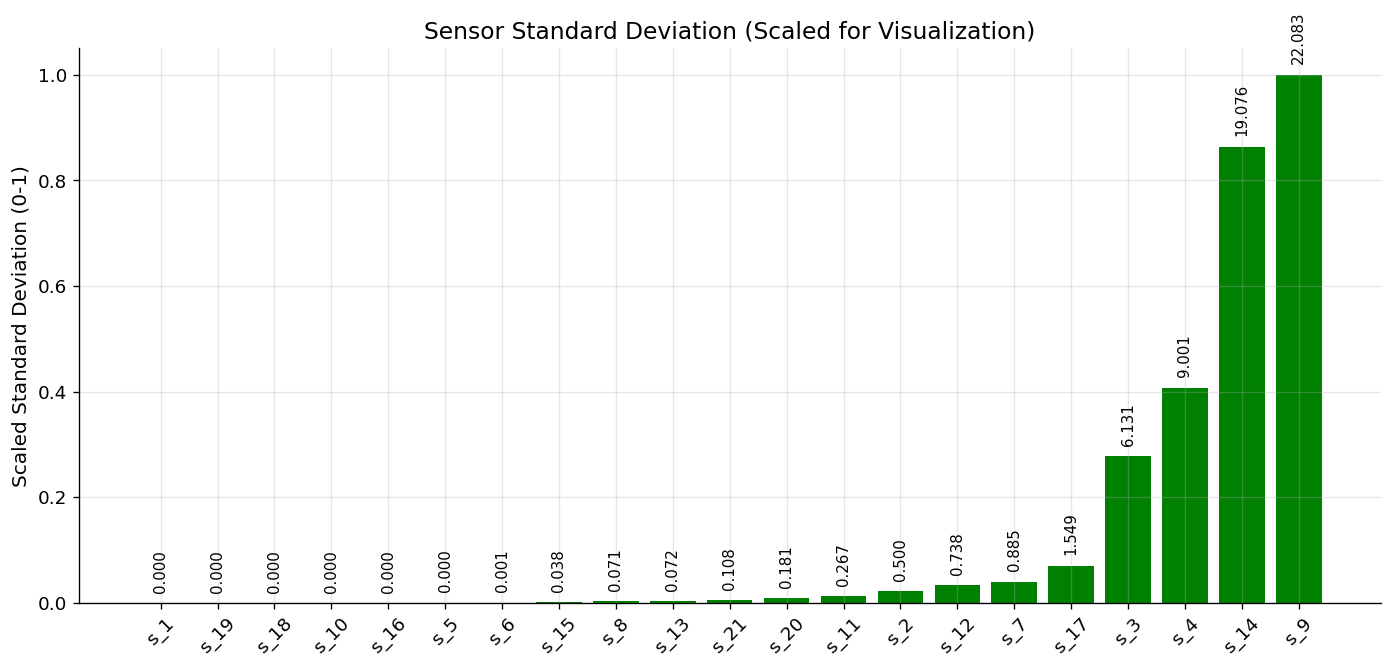

In [53]:
import sklearn
from sklearn.preprocessing import MinMaxScaler

def visualize_sensor_variance_scaled(df, threshold=0.01):
    sensor_cols = [f's_{i}' for i in range(1, 22)]
    sensor_std = df[sensor_cols].std().sort_values()
    
    # Min-Max scaling to 0-1 range
    scaler = MinMaxScaler()
    sensor_std_scaled = scaler.fit_transform(sensor_std.values.reshape(-1, 1)).flatten()
    
    plt.figure(figsize=(14,6))
    colors = ['red' if std < threshold else 'green' for std in sensor_std]  # threshold still in original scale
    
    bars = plt.bar(sensor_std.index, sensor_std_scaled, color=colors)
    
    # Annotate with original std values
    for bar, orig_std in zip(bars, sensor_std.values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{orig_std:.3f}',
                 ha='center', va='bottom', fontsize=9, rotation=90)
    
    plt.title('Sensor Standard Deviation (Scaled for Visualization)', fontsize=14)
    plt.ylabel('Scaled Standard Deviation (0-1)', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
    
    return sensor_std[sensor_std < threshold].index.tolist()

# Compute std for each sensor
sensor_std = df_train[[f's_{i}' for i in range(1, 22)]].std()
# Sort by std
sensor_std_sorted = sensor_std.sort_values()
# Print each sensor with its std
for sensor_name, std_val in sensor_std_sorted.items():
    print(f"{sensor_name}: {std_val:.4f}")

constant_sensors = visualize_sensor_variance_scaled(df_train)

Anything with std ≈ 0 can be safely dropped: s_1, s_5, s_10, s_16, s_18, s_19

Low but not zero (s_6, s_15) — might be near-constant. 
Can consider dropping later if they don’t correlate with RUL.

In [54]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number') 
    max_time_cycles = train_grouped_by_unit['time_cycles'].max() 
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1) 
    return merged
train = add_RUL_column(df_train)
train[['unit_number','RUL']]

,unit_number,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
20626,100,4
20627,100,3
20628,100,2
20629,100,1


In [55]:
#Rul analysis
maxrul_u = train.groupby('unit_number').max().reset_index()
maxrul_u.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,192,0.0047,0.0005,100.0,518.67,644.21,1605.44,1432.52,14.62,...,2388.35,8140.58,8.5227,0.03,398,2388,100.0,39.18,23.4999,191
1,2,287,0.0076,0.0006,100.0,518.67,643.94,1610.10,1431.17,14.62,...,2388.26,8175.57,8.5377,0.03,398,2388,100.0,39.24,23.6005,286
2,3,179,0.0058,0.0005,100.0,518.67,643.93,1606.50,1438.51,14.62,...,2388.20,8255.34,8.5363,0.03,399,2388,100.0,39.23,23.5181,178
3,4,189,0.0059,0.0006,100.0,518.67,644.53,1612.11,1434.12,14.62,...,2388.17,8259.42,8.5462,0.03,399,2388,100.0,39.21,23.5074,188
4,5,269,0.0055,0.0005,100.0,518.67,644.02,1609.41,1434.59,14.62,...,2388.23,8215.19,8.5410,0.03,398,2388,100.0,39.29,23.5503,268


Visualize on RUL column correlation with sensor columns

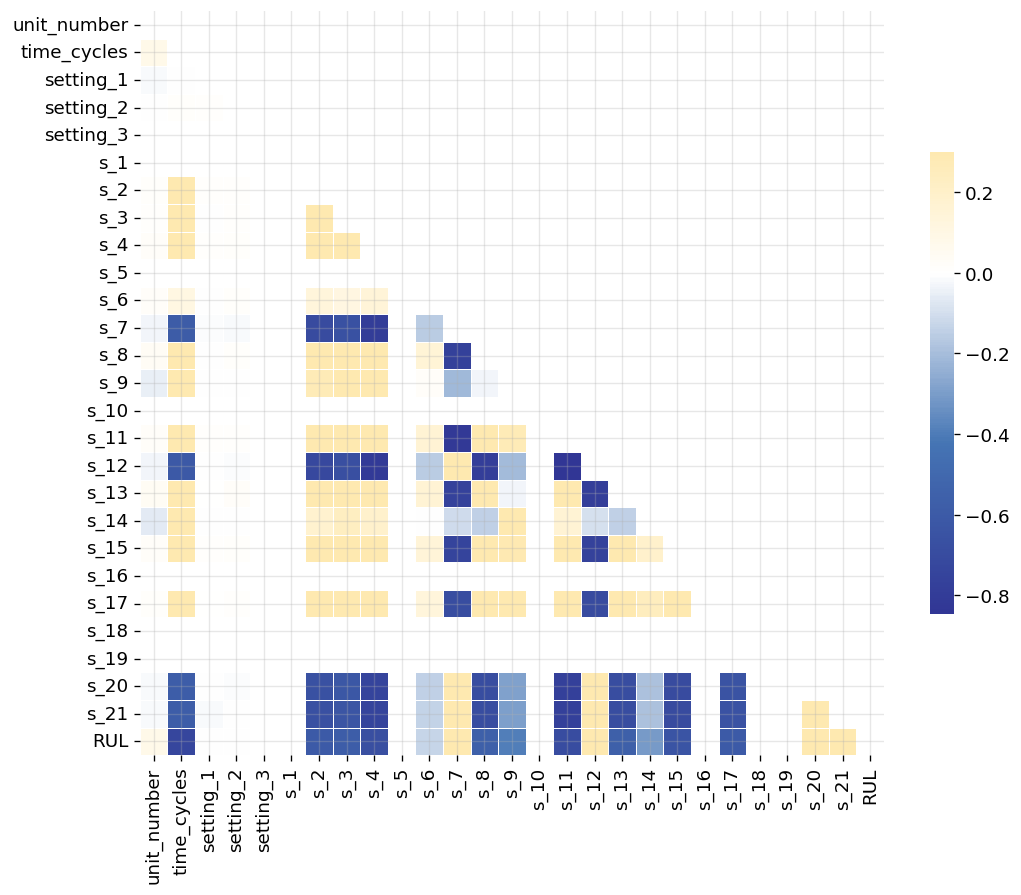

In [56]:
# Create a colormap from your colors
cmap = LinearSegmentedColormap.from_list("custom_cmap", COLORSplt)

# Compute the correlation matrix
corr = train.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))

# Draw the heatmap
sns.heatmap(
    corr, 
    mask=mask, 
    cmap=cmap,        # use your custom colormap
    vmax=.3, 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.show()


We notice that some features of our data-set are highly correlated with the target value RUL, other features present a low correlation which will be dropped later.

Questions to answer :

Can we efficiently predict the remaining useful time for the engine (error significance) ?
Which features are the most important for predicting the failure of the turbofan engine ?
Does adding historical data improve our model ?
Is the collected data sufficient enough to give an accurate prediction ?
How can we turn our problem to a classification one ?

In [57]:
print(f"🔍 Constant sensors to drop (std < 0.01): {constant_sensors}")

df_train = df_train.drop(columns=constant_sensors)
df_test = df_test.drop(columns=constant_sensors)

remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]
print(f"✅ Dropped {len(constant_sensors)} sensors. Remaining: {len(remaining_sensors)}")

🔍 Constant sensors to drop (std < 0.01): ['s_1', 's_19', 's_18', 's_10', 's_16', 's_5', 's_6']
✅ Dropped 7 sensors. Remaining: 14


### 2.3 Diagnostic: Outlier Detection
We examine the distribution of a representative sensor (e.g., `s_9`) to check for extreme outliers that might skew the model.

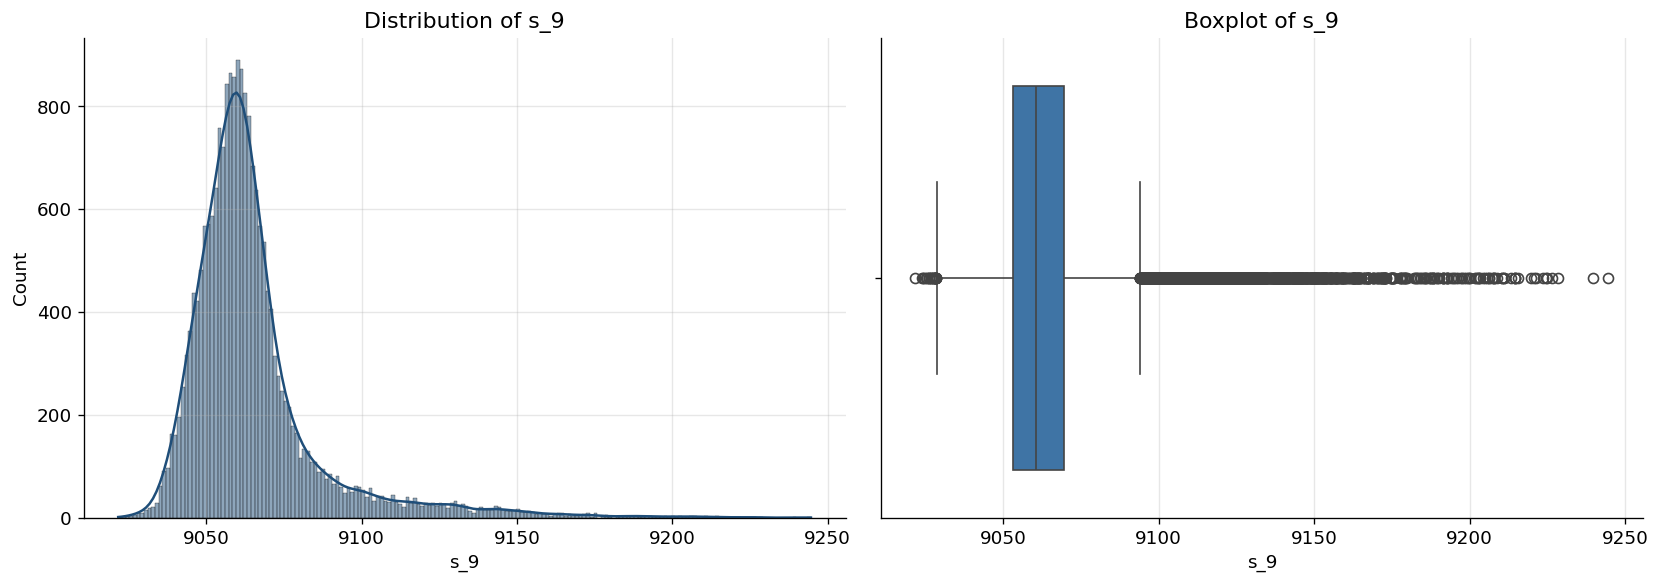

In [58]:
def visualize_outliers(df, sensor_col):
    """Visualize distribution and boxplot for a sensor."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(df[sensor_col], kde=True, ax=ax1, color=COLORS[0])
    ax1.set_title(f'Distribution of {sensor_col}')
    
    sns.boxplot(x=df[sensor_col], ax=ax2, color=COLORS[1])
    ax2.set_title(f'Boxplot of {sensor_col}')
    
    plt.tight_layout()
    plt.show()

visualize_outliers(df_train, 's_9')

**Reasoning**: The boxplot likely shows points outside the whiskers. We will clip values to the 1st and 99th percentiles to mitigate this without deleting rows (which would break time series).

--- Verification: Distribution After Clipping ---


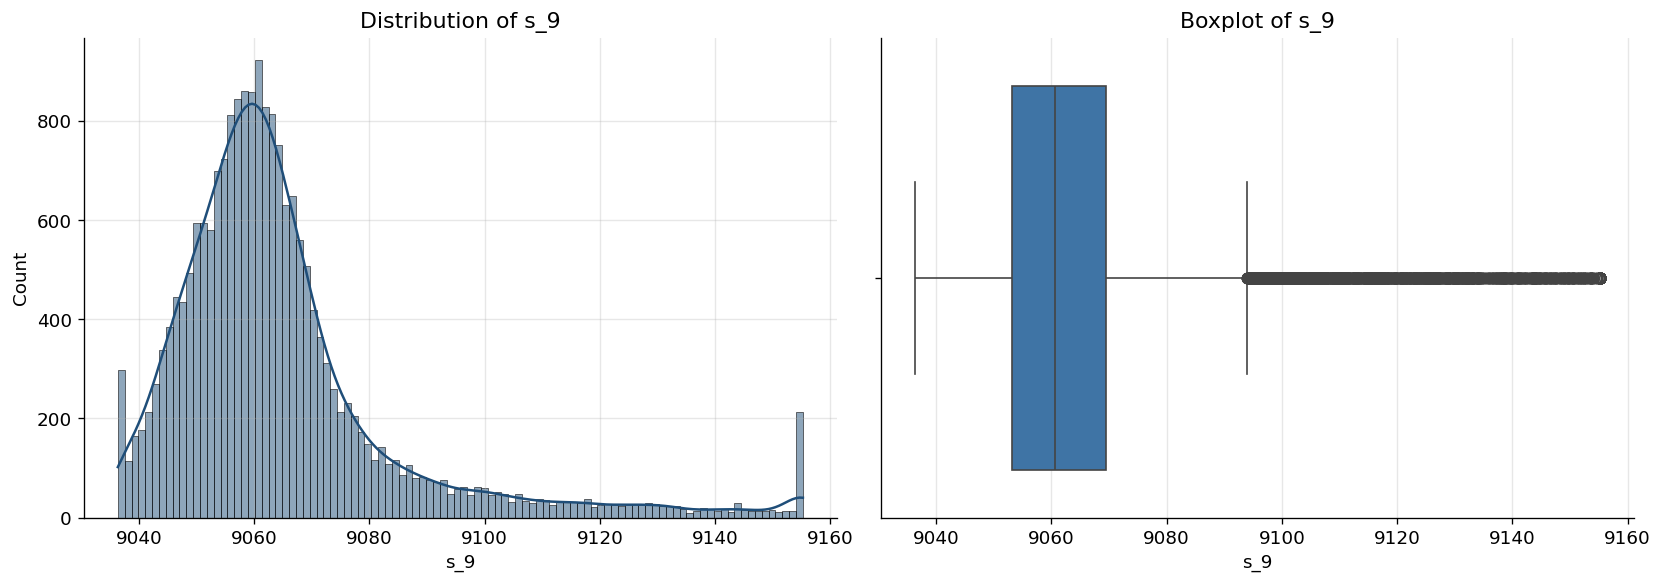

In [59]:
def handle_outliers(df, sensor_cols):
    """Clip outliers to 1st and 99th percentiles (preserve temporal continuity)."""
    df_clipped = df.copy()
    for col in sensor_cols:
        q1, q3 = df_clipped[col].quantile(0.01), df_clipped[col].quantile(0.99)
        df_clipped[col] = df_clipped[col].clip(lower=q1, upper=q3)
    return df_clipped

# Apply Clipping
df_train = handle_outliers(df_train, remaining_sensors)
df_test = handle_outliers(df_test, remaining_sensors)

# Verify Effect
print("--- Verification: Distribution After Clipping ---")
visualize_outliers(df_train, 's_9')

### 2.4 Final Scale Check
Verify the range of sensors after cleaning.

In [60]:
desc_stats = df_train[remaining_sensors].describe().T
print(desc_stats[['mean', 'std', 'min', 'max']])

# Save
df_train.to_csv(PROCESSED_DIR / 'train_cleaned.csv', index=False)
df_test.to_csv(PROCESSED_DIR / 'test_cleaned.csv', index=False)
print(f"\n✅ Cleaned data saved to {PROCESSED_DIR}")

             mean        std        min         max
s_2    642.680751   0.493480   641.6500   643.93000
s_3   1590.519824   6.037949  1577.6130  1605.87100
s_4   1408.927477   8.906258  1391.8830  1431.51700
s_7    553.368224   0.874390   551.1600   555.07000
s_8   2388.096533   0.069961  2387.9600  2388.29000
s_9   9065.036693  20.812184  9036.3500  9155.23900
s_11    47.540997   0.264366    47.0500    48.21000
s_12   521.414000   0.729302   519.5500   522.80000
s_13  2388.096042   0.070674  2387.9600  2388.29000
s_14  8143.580421  17.936673  8115.4160  8220.02000
s_15     8.442128   0.037025     8.3685     8.53507
s_17   393.207891   1.532668   390.0000   397.00000
s_20    38.816492   0.178232    38.3700    39.18000
s_21    23.289753   0.106904    23.0195    23.50884

✅ Cleaned data saved to ../data/processed
